<a href="https://colab.research.google.com/github/rushab14/A2AProject/blob/master/SearchIndex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pypdf sentence-transformers chromadb scikit-learn matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not current

📂 Please upload your file (PDF or TXT):


Saving The largest cat of all, the tiger i.txt to The largest cat of all, the tiger i (3).txt
--- 🚀 Initializing Model: all-MiniLM-L6-v2 ---


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ Loaded 1 chunks.

🔍 Enter search query: give me 2 interesting facts about tigers 
🧠 Encoding 1 chunks...

NumPy:    0.8454 ms
BallTree: 0.1242 ms
Chroma:   12.5451 ms

🎯 Top Match Preview: The largest cat of all, the tiger is a powerful symbol among
the different cultures that share its home. But this
magnificent animal is being persecuted across its range.
Tigers are poisoned, shot, tr...


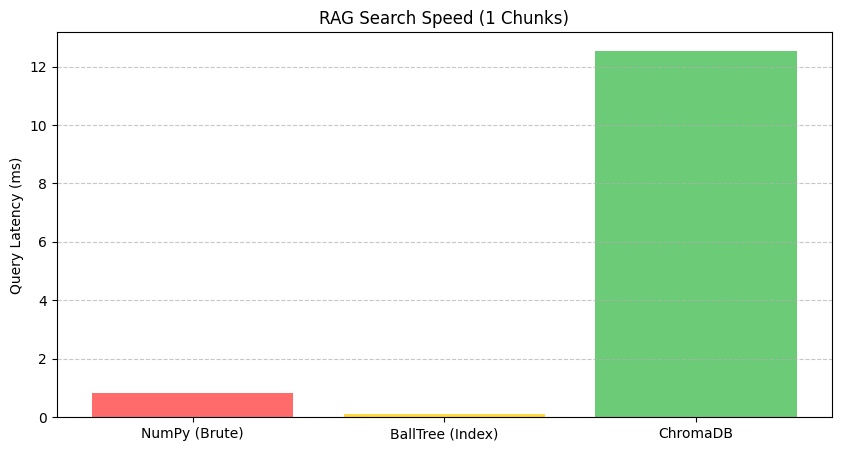

In [ ]:
import time
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from pypdf import PdfReader
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import BallTree
from sklearn.preprocessing import normalize
import chromadb

class RAGComparator:
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        print(f"--- 🚀 Initializing Model: {model_name} ---")
        self.model = SentenceTransformer(model_name)
        # Using Ephemeral Client for Colab (In-Memory)
        self.chroma_client = chromadb.Client()

    def process_pdf(self, path, size=600):
        reader = PdfReader(path)
        text = "".join([p.extract_text() or "" for p in reader.pages])
        return [text[i:i+size] for i in range(0, len(text), size)]

    def process_txt(self, path):
        with open(path, 'r', encoding='utf-8') as f:
            raw_text = f.read()
        return [c.strip() for c in raw_text.split('\n\n') if len(c.strip()) > 20]

    def run_benchmark(self, chunks, query):
        print(f"🧠 Encoding {len(chunks)} chunks...")
        chunk_embeddings = self.model.encode(chunks)
        query_vec = self.model.encode([query])

        # --- Method A: NumPy (Brute Force) ---
        t0 = time.time()
        scores = cosine_similarity(query_vec, chunk_embeddings).flatten()
        best_idx_numpy = np.argmax(scores)
        numpy_time = (time.time() - t0) * 1000

        # --- Method B: BallTree (The Search Index) ---
        # Normalize for Cosine Similarity equivalence
        norm_chunks = normalize(chunk_embeddings)
        norm_query = normalize(query_vec)

        t_build = time.time()
        # leaf_size balances tree depth vs brute force at the bottom
        tree = BallTree(norm_chunks, leaf_size=40)
        build_time = (time.time() - t_build) * 1000

        t_search = time.time()
        dist, ind = tree.query(norm_query, k=1)
        balltree_time = (time.time() - t_search) * 1000

        # --- Method C: ChromaDB ---
        t1 = time.time()
        coll_name = f"compare_{int(time.time()*1000)}"
        collection = self.chroma_client.create_collection(name=coll_name)
        collection.add(
            ids=[str(i) for i in range(len(chunks))],
            embeddings=chunk_embeddings.tolist(),
            documents=chunks
        )
        results = collection.query(query_embeddings=query_vec.tolist(), n_results=1)
        chroma_time = (time.time() - t1) * 1000

        return {
            "numpy_time": numpy_time,
            "balltree_time": balltree_time,
            "balltree_build": build_time,
            "chroma_time": chroma_time,
            "best_text": chunks[ind[0][0]],
            "num_chunks": len(chunks)
        }

    def visualize(self, m):
        plt.figure(figsize=(10, 5))
        methods = ['NumPy (Brute)', 'BallTree (Index)', 'ChromaDB']
        times = [m['numpy_time'], m['balltree_time'], m['chroma_time']]

        colors = ['#FF6B6B', '#FFD93D', '#6BCB77']
        plt.bar(methods, times, color=colors)
        plt.ylabel('Query Latency (ms)')
        plt.title(f'RAG Search Speed ({m["num_chunks"]} Chunks)')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

# --- Execution ---
def main():
    print("📂 Please upload your file (PDF or TXT):")
    uploaded = files.upload()
    if not uploaded:
        return

    file_path = list(uploaded.keys())[0]
    comparator = RAGComparator()

    if file_path.endswith('.pdf'):
        chunks = comparator.process_pdf(file_path)
    else:
        chunks = comparator.process_txt(file_path)

    print(f"\n✅ Loaded {len(chunks)} chunks.")
    query = input("\n🔍 Enter search query: ")

    results = comparator.run_benchmark(chunks, query)

    print("\n" + "="*30)
    print(f"NumPy:    {results['numpy_time']:.4f} ms")
    print(f"BallTree: {results['balltree_time']:.4f} ms")
    print(f"Chroma:   {results['chroma_time']:.4f} ms")
    print("="*30)
    print(f"\n🎯 Top Match Preview: {results['best_text'][:200]}...")

    comparator.visualize(results)
    return chunks

if __name__ == "__main__":
    chuunks = main()

📊 Starting Scaling Benchmark...
Base document has 1 chunks. Scaling up...
⏱️ Testing 100 chunks... 🧠 Encoding 100 chunks...
Done.
⏱️ Testing 500 chunks... 🧠 Encoding 500 chunks...
Done.
⏱️ Testing 1000 chunks... 🧠 Encoding 1000 chunks...
Done.
⏱️ Testing 1500 chunks... 🧠 Encoding 1500 chunks...
Done.
⏱️ Testing 2000 chunks... 🧠 Encoding 2000 chunks...
Done.
⏱️ Testing 2500 chunks... 🧠 Encoding 2500 chunks...
Done.
⏱️ Testing 3000 chunks... 🧠 Encoding 3000 chunks...
Done.
⏱️ Testing 3500 chunks... 🧠 Encoding 3500 chunks...
Done.
⏱️ Testing 4000 chunks... 🧠 Encoding 4000 chunks...
Done.
⏱️ Testing 4500 chunks... 🧠 Encoding 4500 chunks...
Done.
⏱️ Testing 5000 chunks... 🧠 Encoding 5000 chunks...
Done.


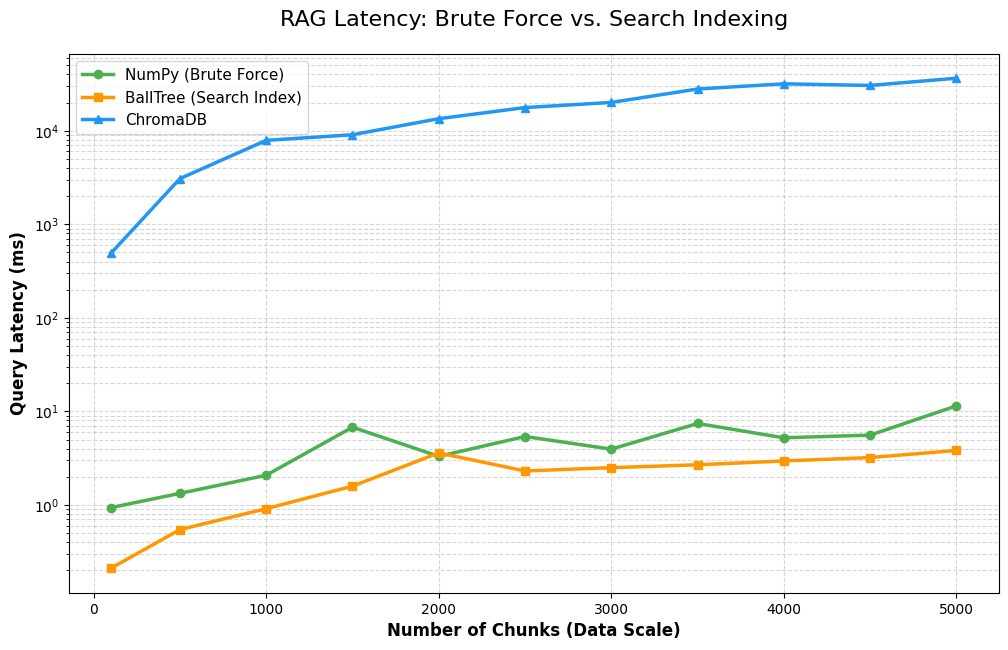


💡 Note: Y-axis is Logarithmic. Small gaps represent massive speed differences!


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import os

def run_scaling_benchmark(base_chunks, query):
    # Scale points: How many chunks to test at each step
    # (We start at 100 and go to 20,000 to see the "cross-over")
    scales = [100, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000]

    results = {
        'scales': scales,
        'numpy': [],
        'balltree': [],
        'chroma': []
    }

    print("📊 Starting Scaling Benchmark...")
    print(f"Base document has {len(base_chunks)} chunks. Scaling up...")

    for size in scales:
        # Create a synthetic dataset of the target size by repeating the base chunks
        multiplier = (size // len(base_chunks)) + 1
        current_chunks = (base_chunks * multiplier)[:size]

        print(f"⏱️ Testing {size} chunks...", end=" ")

        # Run the comparison for this specific size
        m = comparator.run_benchmark(current_chunks, query)

        results['numpy'].append(m['numpy_time'])
        results['balltree'].append(m['balltree_time'])
        results['chroma'].append(m['chroma_time'])
        print("Done.")

    # --- Plotting Results ---
    plt.figure(figsize=(12, 7))

    # Plotting each line with specific colors and markers
    plt.plot(results['scales'], results['numpy'], marker='o', label='NumPy (Brute Force)', color='#4CAF50', linewidth=2.5)
    plt.plot(results['scales'], results['balltree'], marker='s', label='BallTree (Search Index)', color='#FF9800', linewidth=2.5)
    plt.plot(results['scales'], results['chroma'], marker='^', label='ChromaDB', color='#2196F3', linewidth=2.5)

    plt.xlabel('Number of Chunks (Data Scale)', fontsize=12, fontweight='bold')
    plt.ylabel('Query Latency (ms)', fontsize=12, fontweight='bold')
    plt.title('RAG Latency: Brute Force vs. Search Indexing', fontsize=16, pad=20)
    plt.legend(fontsize=11)
    plt.grid(True, which="both", ls="--", alpha=0.5)

    # We use log scale because NumPy will eventually be 100x slower than BallTree
    # This keeps the graph readable!
    plt.yscale('log')

    plt.show()
    print("\n💡 Note: Y-axis is Logarithmic. Small gaps represent massive speed differences!")

# --- GLOBAL CHECK ---
# This part ensures 'chunks' and 'comparator' exist before running
if 'comparator' not in globals():
    comparator = RAGComparator()

# Try to find the chunks from your uploaded file
uploaded_files = [f for f in os.listdir('.') if f.endswith(('.txt', '.pdf'))]
if not uploaded_files:
    print("❌ Error: No file found. Please run the upload cell again!")
else:
    fname = uploaded_files[0]
    # Re-extract chunks globally
    if fname.endswith('.pdf'):
        global_chunks = comparator.process_pdf(fname)
    else:
        global_chunks = comparator.process_txt(fname)

    # RUN THE BENCHMARK
    run_scaling_benchmark(global_chunks, "What are the survival stats for Amur tigers?")